In [1]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import numpy as np
import json
import yaml
import os
import matplotlib.pyplot as plt
import skimage.transform
from PIL import Image

# Import kiến trúc Mạng Đề Xuất
import sys
sys.path.append('../') # Để import được từ thư mục src do notebook nằm trong /notebooks
from src.models.Resnet101 import Encoder
from src.models.Decoder import DecoderWithAttention

# Cấu hình Matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Đang chạy bộ sinh mô tả trên thiết bị: {device}")

🚀 Đang chạy bộ sinh mô tả trên thiết bị: cuda


In [2]:
# 1. Đọc cấu hình từ file yaml
with open('../configs/default.yaml', 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

data_folder = '../' + cfg['dataset']['data_folder']
data_name = cfg['dataset']['data_name']
# CHÚ Ý: Đảm bảo checkpoint này trỏ đến thư mục 'attention'
checkpoint_path = '../models/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar' 
word_map_file = os.path.join(data_folder, f'WORDMAP_{data_name}.json')

# 2. Tải Word Map
with open(word_map_file, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}
vocab_size = len(word_map)

# 3. Tải Checkpoint và Xử lý lệch tên biến
print(f"[*] Đang nạp bộ trọng số từ: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

encoder = Encoder().to(device)
encoder.load_state_dict(checkpoint['encoder'])
encoder.eval()

decoder = DecoderWithAttention(attention_dim=512, embed_dim=512, decoder_dim=512, vocab_size=vocab_size, dropout=0.5).to(device)

state_dict = checkpoint['decoder']
new_state_dict = {k.replace('att.', 'attention.') if k.startswith('att.') else k: v for k, v in state_dict.items()}
decoder.load_state_dict(new_state_dict, strict=False)
decoder.eval()

print("✅ Đã khởi tạo thành công Encoder (ResNet-101) và Decoder (LSTM + Attention)!")

[*] Đang nạp bộ trọng số từ: ../models/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar


C:\Users\leotran\OneDrive\Desktop\ThS_PTIT_HTTT\AI\Final_term\Final\env_gpu\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\leotran\OneDrive\Desktop\ThS_PTIT_HTTT\AI\Final_term\Final\env_gpu\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Đã khởi tạo thành công Encoder (ResNet-101) và Decoder (LSTM + Attention)!


In [3]:
def caption_image_beam_search_single(encoder, decoder, image_path, word_map, beam_size=5):
    """Suy luận câu mô tả cho một bức ảnh và trả về trọng số Attention."""
    k = beam_size
    vocab_size = len(word_map)

    # Tiền xử lý ảnh (Giống lúc Train)
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img = Image.open(image_path).convert('RGB')
    image = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_out = encoder(image)  # (1, enc_image_size, enc_image_size, encoder_dim)

    enc_image_size = encoder_out.size(1)
    encoder_dim = encoder_out.size(3)
    encoder_out = encoder_out.view(1, -1, encoder_dim).expand(k, -1, encoder_dim)

    k_prev_words = torch.full((k, 1), word_map['<start>'], dtype=torch.long, device=device)
    seqs = k_prev_words
    top_k_scores = torch.zeros(k, 1, device=device)
    seqs_alpha = torch.ones(k, 1, enc_image_size, enc_image_size, device=device)

    h_state, c_state = decoder.init_hidden_state(encoder_out)
    step = 1
    complete_seqs, complete_seqs_alphas, complete_seqs_scores = [], [], []

    while True:
        embeddings = decoder.embedding(k_prev_words).squeeze(1)
        awe, alpha = decoder.attention(encoder_out, h_state)
        alpha = alpha.view(-1, enc_image_size, enc_image_size)

        gate = decoder.sigmoid(decoder.f_beta(h_state))
        awe = gate * awe

        h_state, c_state = decoder.decode_step(torch.cat([embeddings, awe], dim=1), (h_state, c_state))
        scores = F.log_softmax(decoder.fc(h_state), dim=1)
        scores = top_k_scores.expand_as(scores) + scores

        if step == 1:
            top_k_scores, top_k_words = scores[0].topk(k, 0, True, True)
        else:
            top_k_scores, top_k_words = scores.view(-1).topk(k, 0, True, True)

        prev_word_inds = top_k_words // vocab_size
        next_word_inds = top_k_words % vocab_size

        seqs = torch.cat([seqs[prev_word_inds], next_word_inds.unsqueeze(1)], dim=1)
        seqs_alpha = torch.cat([seqs_alpha[prev_word_inds], alpha[prev_word_inds].unsqueeze(1)], dim=1)

        incomplete_inds = [ind for ind, next_word in enumerate(next_word_inds) if next_word != word_map['<end>']]
        complete_inds = list(set(range(len(next_word_inds))) - set(incomplete_inds))

        if len(complete_inds) > 0:
            complete_seqs.extend(seqs[complete_inds].tolist())
            complete_seqs_alphas.extend(seqs_alpha[complete_inds].tolist())
            complete_seqs_scores.extend(top_k_scores[complete_inds].cpu().tolist())
        
        k -= len(complete_inds)
        if k == 0 or step > 50:
            break

        seqs = seqs[incomplete_inds]
        seqs_alpha = seqs_alpha[incomplete_inds]
        h_state = h_state[prev_word_inds[incomplete_inds]]
        c_state = c_state[prev_word_inds[incomplete_inds]]
        encoder_out = encoder_out[prev_word_inds[incomplete_inds]]
        top_k_scores = top_k_scores[incomplete_inds].unsqueeze(1)
        k_prev_words = next_word_inds[incomplete_inds].unsqueeze(1)
        step += 1

    if not complete_seqs_scores:
        return seqs[0].tolist(), seqs_alpha[0].tolist()

    best_idx = complete_seqs_scores.index(max(complete_seqs_scores))
    return complete_seqs[best_idx], complete_seqs_alphas[best_idx]

In [4]:
def visualize_attention(image_path, seq, alphas, rev_word_map, smooth=True):
    """Hiển thị ảnh gốc và cường độ Attention tương ứng với từng từ sinh ra."""
    image = Image.open(image_path).convert('RGB')
    image = image.resize([14 * 24, 14 * 24], Image.LANCZOS)
    
    words = [rev_word_map[ind] for ind in seq]
    
    # Tính toán layout lưới (Tối đa 4 cột)
    cols = 4
    rows = (len(words) + cols - 1) // cols
    
    fig = plt.figure(figsize=(16, 4 * rows))
    
    for t in range(len(words)):
        if t > 50: break
        
        ax = fig.add_subplot(rows, cols, t + 1)
        # Bỏ đi các token hệ thống để caption đẹp hơn
        display_word = words[t] if words[t] not in ['<start>', '<end>', '<pad>'] else ''
        ax.set_title(display_word, fontsize=16, fontweight='bold', color='darkred')
        ax.imshow(image)
        
        current_alpha = alphas[t]
        if smooth:
            alpha = skimage.transform.pyramid_expand(np.array(current_alpha), upscale=24, sigma=8)
        else:
            alpha = skimage.transform.resize(np.array(current_alpha), [14 * 24, 14 * 24])
            
        if t == 0:
            ax.imshow(alpha, alpha=0) # Không vẽ attention cho token <start>
        else:
            ax.imshow(alpha, alpha=0.7, cmap='jet')
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

✨ Kết quả sinh mô tả: "Two pictures of a man cutting a cake."


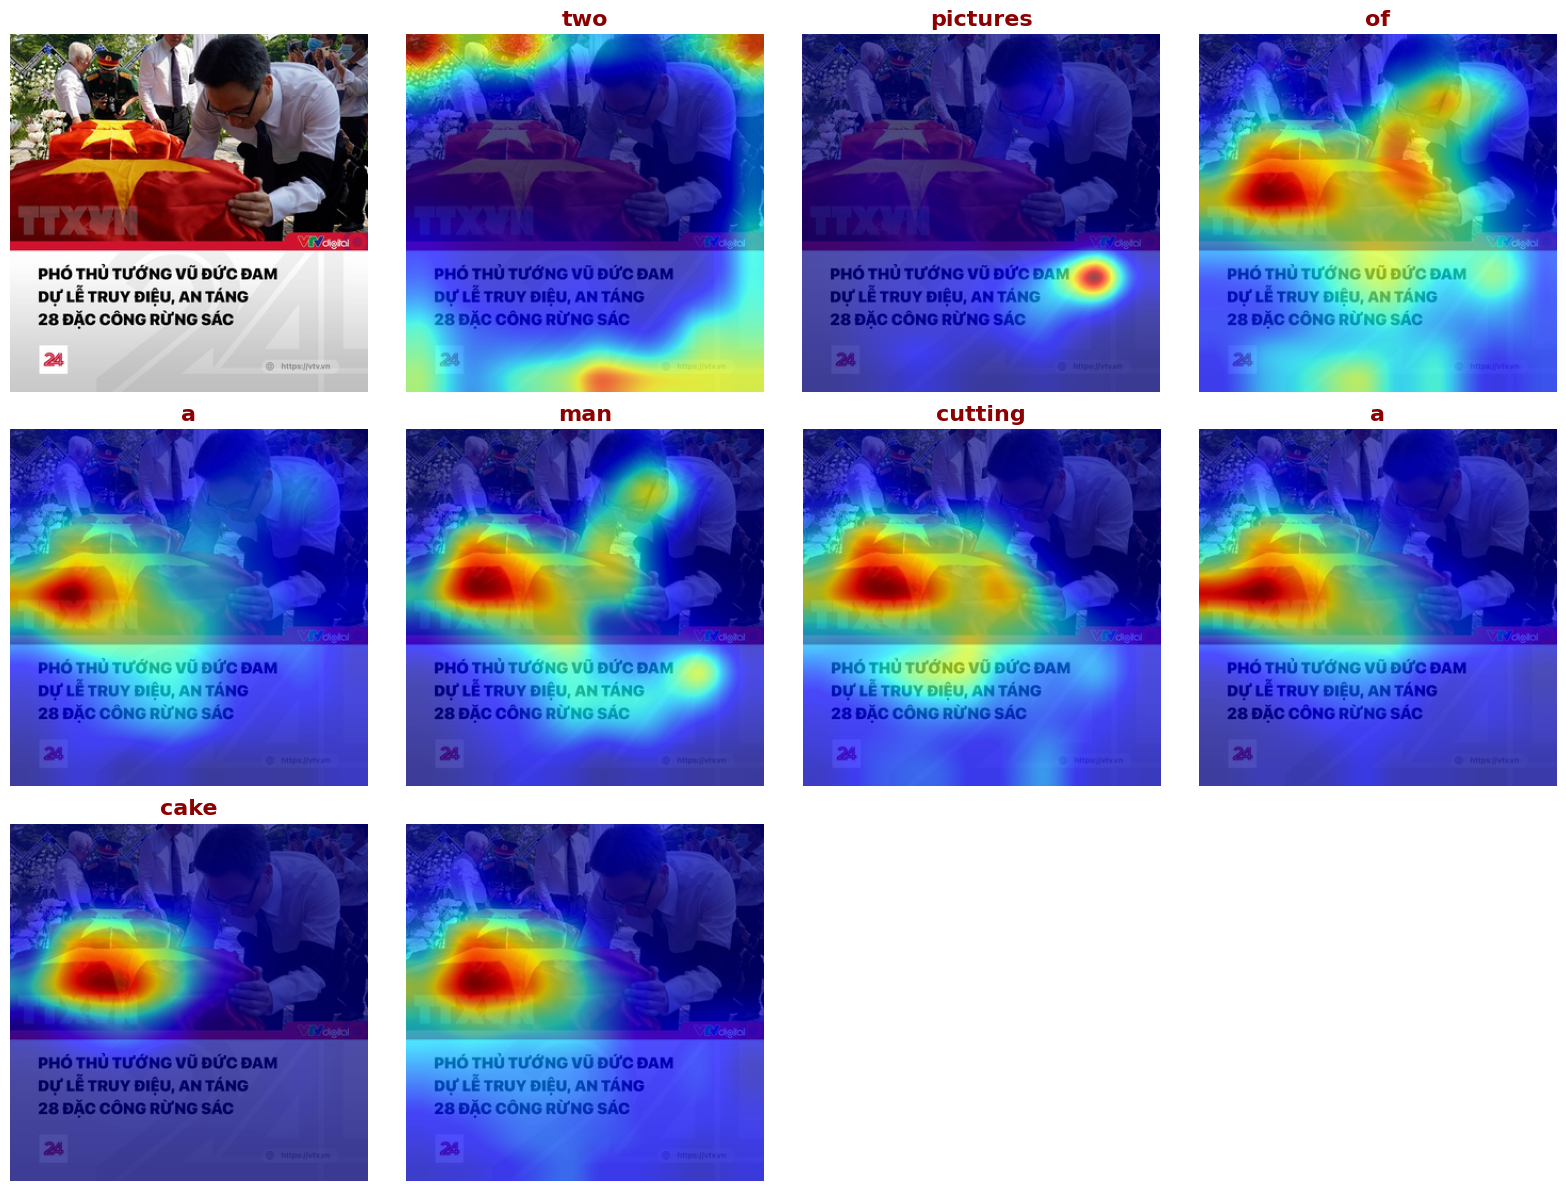

In [5]:
# Hãy chọn một bức ảnh bất kỳ từ VTV24
test_image_path = '../self_collect/img/111.jpg' 

# 1. Sinh mô tả
seq, alphas = caption_image_beam_search_single(encoder, decoder, test_image_path, word_map, beam_size=5)

# 2. Xử lý chuỗi kết quả
words = [rev_word_map[ind] for ind in seq if ind not in [word_map['<start>'], word_map['<end>'], word_map['<pad>']]]
caption = ' '.join(words)

print(f"✨ Kết quả sinh mô tả: \"{caption.capitalize()}.\"")

# 3. Trực quan hóa
visualize_attention(test_image_path, seq, alphas, rev_word_map)